# 04 — Reward Model Training (Bradley-Terry)

Train a neural network reward model using pairwise human preference data. The model learns `r(trajectory)` such that `P(A > B) = σ(r(A) - r(B))`.

In [1]:
import sys
sys.path.insert(0, '../src')

import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from pathlib import Path

from lunarlander.reward_model import RewardModel
from lunarlander.preference_dataset import PairwisePreferenceDataset
from lunarlander.db_logger import ExperimentLogger

DATA_DIR = Path('../data')
CHECKPOINT_DIR = Path('../checkpoints')
DB_PATH = Path('../experiments.db')

PAIRS_PATH = DATA_DIR / 'preference_pairs.pkl'
META_PATH = DATA_DIR / 'dataset_meta.pkl'
MODEL_PATH = CHECKPOINT_DIR / 'reward_model.pt'

assert PAIRS_PATH.exists(), f'Run notebook 03 first! Missing {PAIRS_PATH}'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [ ]:
# Hyperparameters
N_EPOCHS = 100
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.15
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

with open(META_PATH, 'rb') as f:
    meta = pickle.load(f)
FEAT_DIM = meta['feat_dim']
print(f'Feature dim: {FEAT_DIM}  |  Training pairs: {meta["n_pairs"]}')

hyperparams = {
    'n_epochs': N_EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'feat_dim': FEAT_DIM,
    'val_split': VAL_SPLIT,
    'architecture': 'MLP [feat_dim->128->64->1]',
    'loss': 'Bradley-Terry cross-entropy',
    'optimizer': 'AdamW',
    'seed': SEED,
}

In [3]:
# Load dataset and split train/val
dataset = PairwisePreferenceDataset(PAIRS_PATH)

n_val = int(len(dataset) * VAL_SPLIT)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {n_train} pairs, Val: {n_val} pairs')

Loaded 1000 preference pairs from ../data/preference_pairs.pkl
Train: 850 pairs, Val: 150 pairs


In [4]:
# Bradley-Terry loss function
def bradley_terry_loss(r_a: torch.Tensor, r_b: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    """
    Bradley-Terry preference model loss.
    P(A > B) = σ(r(A) - r(B))
    L = -[label * log σ(r_A - r_B) + (1 - label) * log σ(r_B - r_A)]
    """
    r_a = r_a.squeeze(-1)
    r_b = r_b.squeeze(-1)
    logits = r_a - r_b
    loss = nn.functional.binary_cross_entropy_with_logits(logits, labels)
    return loss


def compute_accuracy(r_a, r_b, labels):
    r_a = r_a.squeeze(-1)
    r_b = r_b.squeeze(-1)
    preds = (r_a > r_b).float()
    return (preds == labels).float().mean().item()


print('Loss function defined.')

Loss function defined.


In [5]:
# Initialise model and optimiser
model = RewardModel(feat_dim=FEAT_DIM).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Model parameters: 9,985
RewardModel(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [6]:
# Training loop
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float('inf')

for epoch in range(1, N_EPOCHS + 1):
    # --- Train ---
    model.train()
    ep_loss, ep_acc = 0.0, 0.0
    for feat_a, feat_b, labels in train_loader:
        feat_a, feat_b, labels = feat_a.to(DEVICE), feat_b.to(DEVICE), labels.to(DEVICE)
        r_a = model(feat_a)
        r_b = model(feat_b)
        loss = bradley_terry_loss(r_a, r_b, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
        ep_acc += compute_accuracy(r_a.detach(), r_b.detach(), labels)

    train_losses.append(ep_loss / len(train_loader))
    train_accs.append(ep_acc / len(train_loader))

    # --- Validate ---
    model.eval()
    vl_loss, vl_acc = 0.0, 0.0
    with torch.no_grad():
        for feat_a, feat_b, labels in val_loader:
            feat_a, feat_b, labels = feat_a.to(DEVICE), feat_b.to(DEVICE), labels.to(DEVICE)
            r_a = model(feat_a)
            r_b = model(feat_b)
            vl_loss += bradley_terry_loss(r_a, r_b, labels).item()
            vl_acc += compute_accuracy(r_a, r_b, labels)

    val_losses.append(vl_loss / len(val_loader))
    val_accs.append(vl_acc / len(val_loader))
    scheduler.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
              f'Train loss={train_losses[-1]:.4f} acc={train_accs[-1]:.3f} | '
              f'Val loss={val_losses[-1]:.4f} acc={val_accs[-1]:.3f}')

    # Save best
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        model.save(MODEL_PATH)

print(f'\nTraining complete! Best val loss: {best_val_loss:.4f}')

Epoch   1/50 | Train loss=0.6856 acc=0.623 | Val loss=0.6772 acc=0.598
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Epoch  10/50 | Train loss=0.5713 acc=0.705 | Val loss=0.5744 acc=0.691
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward model saved to ../checkpoints/reward_model.pt
Reward mod

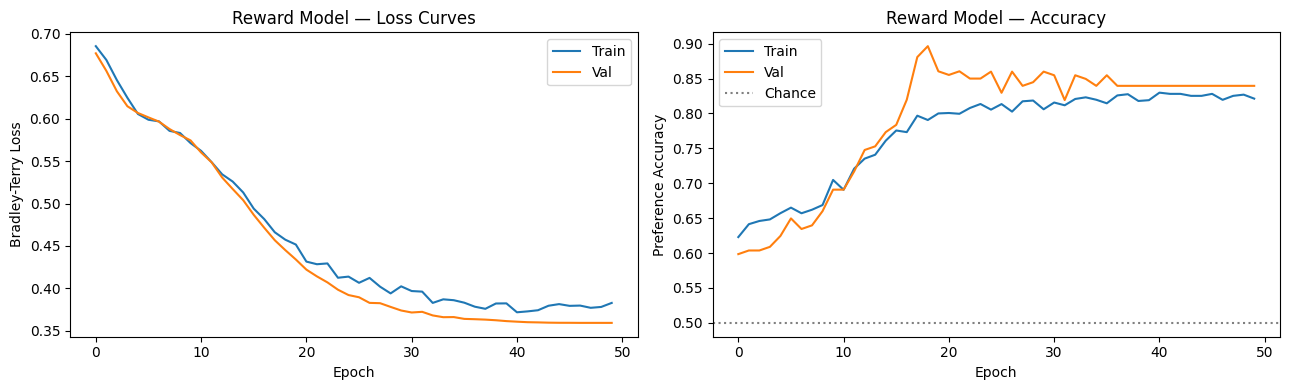

In [7]:
# Plot training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses, label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Bradley-Terry Loss')
axes[0].set_title('Reward Model — Loss Curves')
axes[0].legend()

axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Val')
axes[1].axhline(0.5, color='gray', linestyle=':', label='Chance')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Preference Accuracy')
axes[1].set_title('Reward Model — Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../checkpoints/reward_model_training.png', dpi=100)
plt.show()

In [8]:
# Log to SQLite
final_val_acc = val_accs[-1]
logger = ExperimentLogger(DB_PATH)
row_id = logger.log(
    name='Bradley-Terry Reward Model',
    exp_type='reward_model',
    mean_reward=None,
    std_reward=None,
    success_rate=final_val_acc,  # repurpose field for preference accuracy
    hyperparams=hyperparams,
    notes=(
        f'Bradley-Terry MLP reward model. '
        f'Final val loss={best_val_loss:.4f}, val acc={final_val_acc:.3f}. '
        f'Saved to {MODEL_PATH}.'
    ),
)
print(f'Logged to SQLite, row id={row_id}')

Logged to SQLite, row id=5
